In [344]:
# Import Required Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn

In [345]:
# Load the Customer Churn dataset into a pandas DataFrame for data preprocessing, exploratory data analysis (EDA), and machine learning.
df=pd.read_csv(r'C:\Users\rehan\OneDrive\Desktop\Data Science\6-Months-Data-Science\Customer_churn_project\data\Telco-Customer-Churn.csv')

In [346]:
# Display the DataFrame to inspect the dataset and verify that it has been loaded successfully.
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [347]:
# Retrieve all unique customer IDs to verify the uniqueness of each customer record.
df['customerID'].unique()

<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

In [348]:
# Remove the 'customerID' column as it serves only as a unique identifier and does not contribute to predictive modeling.
df.drop('customerID',axis=1,inplace=True)

In [349]:
# Remove duplicate records to improve data quality.
df.drop_duplicates(inplace=True)

In [350]:
df.dropna(inplace=True)

In [351]:
# Check the dataset for duplicate records and missing values to assess data quality before preprocessing.
print("duplicate values : ",df.duplicated().sum())
print("Null values : ",df.isnull().sum())

duplicate values :  0
Null values :  gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [352]:
# Display the unique values in the 'gender' column.
df['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [353]:
# Clean and encode the 'gender' column into numeric values.
df['gender']=df['gender'].str.strip().str.title().map({'Female':0,'Male':1})

In [354]:
# Display the unique values in the 'Partner' column.
df['Partner'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [355]:
# Clean and encode the 'Partner' column into numeric values.
df['Partner']=df['Partner'].str.strip().str.title().map({'No':0,'Yes':1})


In [356]:
# Display the unique values in the 'Dependents' column.
df['Dependents'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [357]:
# Clean and encode the 'Dependents' column into numeric values.
df['Dependents']=df['Dependents'].str.strip().str.title().map({'No':0,'Yes':1})

In [358]:
# Display the unique values in the 'PhoneService' column.
df['PhoneService'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [359]:
# Clean and encode the 'PhoneService' column into numeric values.
df['PhoneService']=df['PhoneService'].str.strip().str.title().map({'No':0,'Yes':1})


In [360]:
# Display the unique values in the 'MultipleLines' column.
df['MultipleLines'].unique()

<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

In [361]:
# Clean and encode the 'MultipleLines' column into numeric values.
df['MultipleLines'] = df['MultipleLines'].str.strip().str.title().map({
    'No Phone Service': 0,
    'No': 1,
    'Yes': 2
})

In [362]:
# Display the unique values in the 'InternetService' column.
df['InternetService'].unique()

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

In [363]:
# Clean and encode the 'InternetService' column into numeric values.
df['InternetService']=df['InternetService'].str.strip().str.title().map({
    'Dsl':1,
    'Fiber Optic':2,
    'No':0
})

In [364]:
# Display the unique values in the 'OnlineSecurity' column.
df['OnlineSecurity'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [365]:
# Clean and encode the 'OnlineSecurity' column into numeric values.
df['OnlineSecurity']=df['OnlineSecurity'].str.strip().str.title().map({'No':1,'No Internet Service':0,'Yes':2})

In [366]:
# Display the unique values in the 'OnlineBackup' column.
df['OnlineBackup'].unique()

<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

In [367]:
# Clean and encode the 'OnlineBackup' column into numeric values.
df['OnlineBackup']=df['OnlineBackup'].str.strip().str.title().map({'No Internet Service':0,'No':1,'Yes':2})

In [368]:
# Display the unique values in the 'DeviceProtection' column.
df['DeviceProtection'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [369]:
# Clean and encode the 'DeviceProtection' column into numeric values.
df['DeviceProtection']=df['DeviceProtection'].str.strip().str.title().map({'No Internet Service':0,'No':1,'Yes':2})

In [370]:
# Display the unique values in the 'TechSupport' column.
df['TechSupport'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [371]:
# Clean and encode the 'TechSupport' column into numeric values.
df['TechSupport']=df['TechSupport'].str.strip().str.title().map({'No Internet Service':0,'No':1,'Yes':2})

In [372]:
# Display the unique values in the 'StreamingTV' column.
df['StreamingTV'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [373]:
# Clean and encode the 'StreamingTV' column into numeric values.
df['StreamingTV']=df['StreamingTV'].str.strip().str.title().map({'No Internet Service':0,'No':1,'Yes':2})

In [374]:
# Display the unique values in the 'StreamingMovies' column.
df['StreamingMovies'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [375]:
# Clean and encode the 'StreamingMovies' column into numeric values.
df['StreamingMovies']=df['StreamingMovies'].str.strip().str.title().map({'No Internet Service':0,'No':1,'Yes':2})

In [376]:
# Display the unique values in the 'Contract' column.
df['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [377]:
# Clean and encode the 'Contract' column into numeric values.
df['Contract'] = df['Contract'].str.strip().str.title().map({
    'Month-To-Month': 0,
    'One Year': 1,
    'Two Year': 2
})

In [378]:
# Display the unique values in the 'PaperlessBilling' column.
df['PaperlessBilling'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [379]:
# Clean and encode the 'PaperlessBilling' column into numeric values.
df['PaperlessBilling'] = df['PaperlessBilling'].str.strip().map({
    'No': 0,
    'Yes': 1
})

In [380]:
# Display the unique values in the 'PaymentMethod' column.
df['PaymentMethod'].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [381]:
# Clean and encode the 'PaymentMethod' column into numeric values.
df['PaymentMethod'] = df['PaymentMethod'].str.strip().map({
    'Electronic check': 0,
    'Mailed check': 1,
    'Bank transfer (automatic)': 2,
    'Credit card (automatic)': 3
})

In [382]:
# Display the unique values in the 'Churn' column.
df['Churn'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [383]:
# Clean and encode the 'Churn' column into numeric values.
df['Churn']=df['Churn'].str.strip().map({'No':0,'Yes':1})

In [384]:
# Display the first few rows of the dataset
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,1,1,2,1,1,1,1,0,1,0,29.85,29.85,0
1,1,0,0,0,34,1,1,1,2,1,2,1,1,1,1,0,1,56.95,1889.5,0
2,1,0,0,0,2,1,1,1,2,2,1,1,1,1,0,1,1,53.85,108.15,1
3,1,0,0,0,45,0,0,1,2,1,2,2,1,1,1,0,2,42.30,1840.75,0
4,0,0,0,0,2,1,1,2,1,1,1,1,1,1,0,1,0,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,1,2,1,2,2,2,2,1,1,1,84.80,1990.5,0
7039,0,0,1,1,72,1,2,2,1,2,2,1,2,2,1,1,3,103.20,7362.9,0
7040,0,0,1,1,11,0,0,1,2,1,1,1,1,1,0,1,0,29.60,346.45,0
7041,1,1,1,0,4,1,2,2,1,1,1,1,1,1,0,1,1,74.40,306.6,1


In [385]:
# Separate the independent features (X) by dropping the target column
x=df.drop('Churn',axis=1)

In [386]:
# Create the target variable (y) by selecting the Churn column
y=df[['Churn']]

In [387]:
# Display the feature dataset (X)
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,0,1,1,2,1,1,1,1,0,1,0,29.85,29.85
1,1,0,0,0,34,1,1,1,2,1,2,1,1,1,1,0,1,56.95,1889.5
2,1,0,0,0,2,1,1,1,2,2,1,1,1,1,0,1,1,53.85,108.15
3,1,0,0,0,45,0,0,1,2,1,2,2,1,1,1,0,2,42.30,1840.75
4,0,0,0,0,2,1,1,2,1,1,1,1,1,1,0,1,0,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,1,2,1,2,2,2,2,1,1,1,84.80,1990.5
7039,0,0,1,1,72,1,2,2,1,2,2,1,2,2,1,1,3,103.20,7362.9
7040,0,0,1,1,11,0,0,1,2,1,1,1,1,1,0,1,0,29.60,346.45
7041,1,1,1,0,4,1,2,2,1,1,1,1,1,1,0,1,1,74.40,306.6


In [388]:
# Display the target variable (y)
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [389]:
# Display the number of rows and columns in the dataset
df.shape

(7021, 20)

In [390]:
# Display the first five rows of the dataset
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,1,1,2,1,1,1,1,0,1,0,29.85,29.85,0
1,1,0,0,0,34,1,1,1,2,1,2,1,1,1,1,0,1,56.95,1889.5,0
2,1,0,0,0,2,1,1,1,2,2,1,1,1,1,0,1,1,53.85,108.15,1
3,1,0,0,0,45,0,0,1,2,1,2,2,1,1,1,0,2,42.30,1840.75,0
4,0,0,0,0,2,1,1,2,1,1,1,1,1,1,0,1,0,70.70,151.65,1


In [391]:
# Display the last five rows of the dataset
df.tail()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,1,0,1,1,24,1,2,1,2,1,2,2,2,2,1,1,1,84.80,1990.5,0
7039,0,0,1,1,72,1,2,2,1,2,2,1,2,2,1,1,3,103.20,7362.9,0
7040,0,0,1,1,11,0,0,1,2,1,1,1,1,1,0,1,0,29.60,346.45,0
7041,1,1,1,0,4,1,2,2,1,1,1,1,1,1,0,1,1,74.40,306.6,1
7042,1,0,0,0,66,1,1,2,2,1,2,2,2,2,2,1,2,105.65,6844.5,0


In [392]:
# Display the dataset information, including data types and non-null values
df.info()

<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   int64  
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   int64  
 3   Dependents        7021 non-null   int64  
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   int64  
 6   MultipleLines     7021 non-null   int64  
 7   InternetService   7021 non-null   int64  
 8   OnlineSecurity    7021 non-null   int64  
 9   OnlineBackup      7021 non-null   int64  
 10  DeviceProtection  7021 non-null   int64  
 11  TechSupport       7021 non-null   int64  
 12  StreamingTV       7021 non-null   int64  
 13  StreamingMovies   7021 non-null   int64  
 14  Contract          7021 non-null   int64  
 15  PaperlessBilling  7021 non-null   int64  
 16  PaymentMethod     7021 non-null   int64  
 17  MonthlyChar

In [393]:
# make Nan if any blank and invalid string in TotalCharges column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [394]:
# chek how many null values
print("Missing values found:", df['TotalCharges'].isnull().sum())

Missing values found: 11


In [395]:
# Remove rows with missing values in the TotalCharges column
df.dropna(subset=['TotalCharges'], inplace=True)

In [396]:
# Convert the TotalCharges column to float data type
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [397]:
df.info()

<class 'pandas.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   int64  
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   int64  
 3   Dependents        7010 non-null   int64  
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   int64  
 6   MultipleLines     7010 non-null   int64  
 7   InternetService   7010 non-null   int64  
 8   OnlineSecurity    7010 non-null   int64  
 9   OnlineBackup      7010 non-null   int64  
 10  DeviceProtection  7010 non-null   int64  
 11  TechSupport       7010 non-null   int64  
 12  StreamingTV       7010 non-null   int64  
 13  StreamingMovies   7010 non-null   int64  
 14  Contract          7010 non-null   int64  
 15  PaperlessBilling  7010 non-null   int64  
 16  PaymentMethod     7010 non-null   int64  
 17  MonthlyChar

In [398]:
# Display summary statistics of the numerical columns
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.504280,0.162767,0.484023,0.299429,32.520399,0.902996,1.326248,1.225963,1.072611,1.131098,1.130100,1.076177,1.170756,1.174750,0.690728,0.593153,1.317404,64.888666,2290.353388,0.264907
std,0.500017,0.369180,0.499780,0.458041,24.520441,0.295985,0.643333,0.777600,0.705040,0.737334,0.736833,0.707190,0.755878,0.757606,0.833345,0.491281,1.150581,30.064769,2266.820832,0.441315
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,35.750000,408.312500,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,70.400000,1403.875000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,56.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,89.900000,3807.837500,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,118.750000,8684.800000,1.000000


In [399]:
# Check the total number of missing values in each column
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

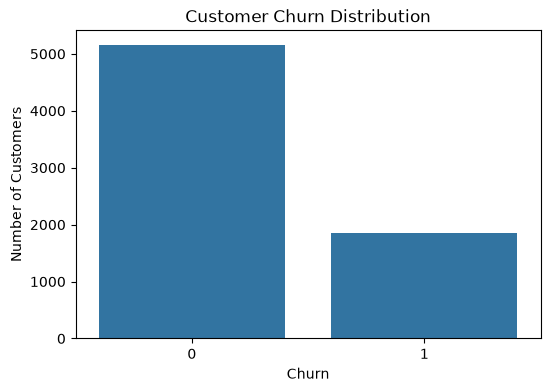

In [400]:
# Visualize the distribution of customer churn using a count plot

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

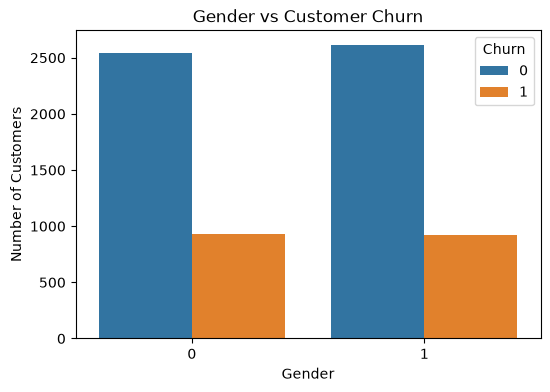

In [401]:
# Visualize the relationship between gender and customer churn
plt.figure(figsize=(6,4))

sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

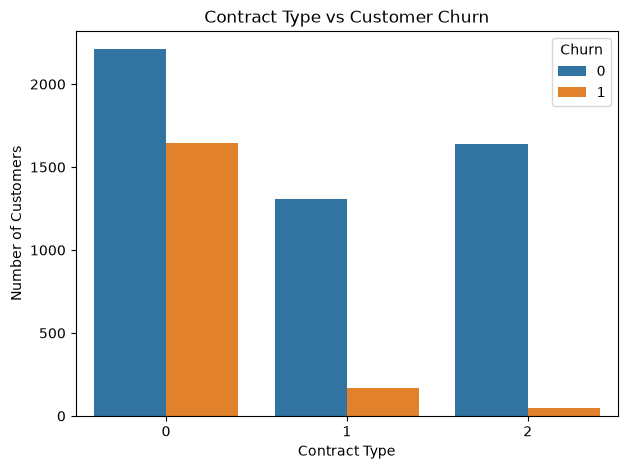

In [402]:
# Visualize the relationship between contract type and customer churn
plt.figure(figsize=(7,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

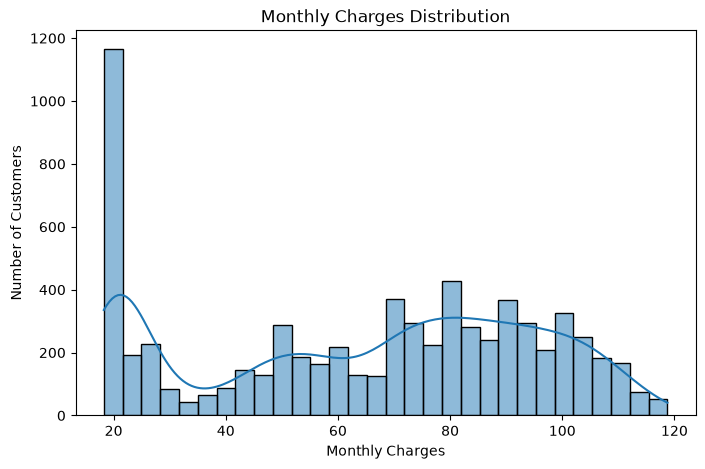

In [403]:
# Visualize the distribution of monthly charges using a histogram
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], bins=30, kde=True)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

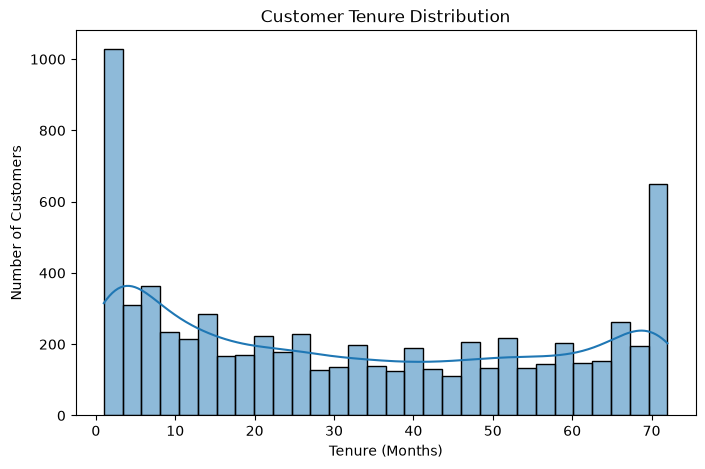

In [404]:
# Visualize the distribution of customer tenure using a histogram
plt.figure(figsize=(8,5))

sns.histplot(df['tenure'], bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

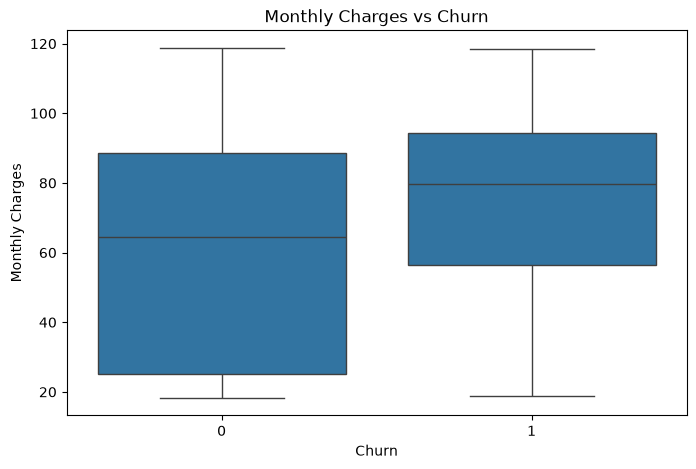

In [405]:
# Compare monthly charges across churn categories using a box plot
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

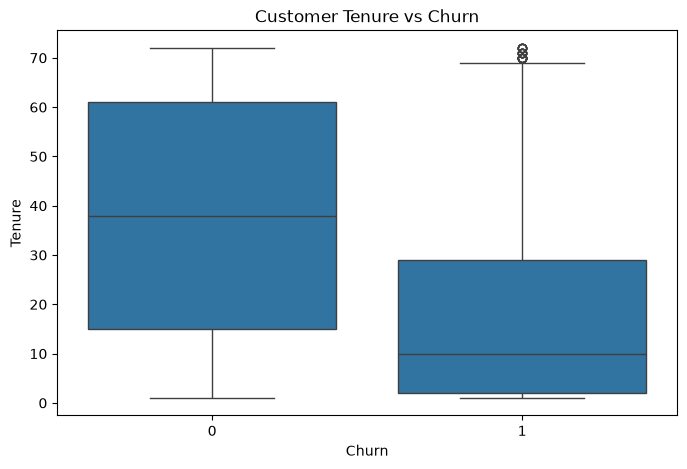

In [406]:
# Compare customer tenure across churn categories using a box plot
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

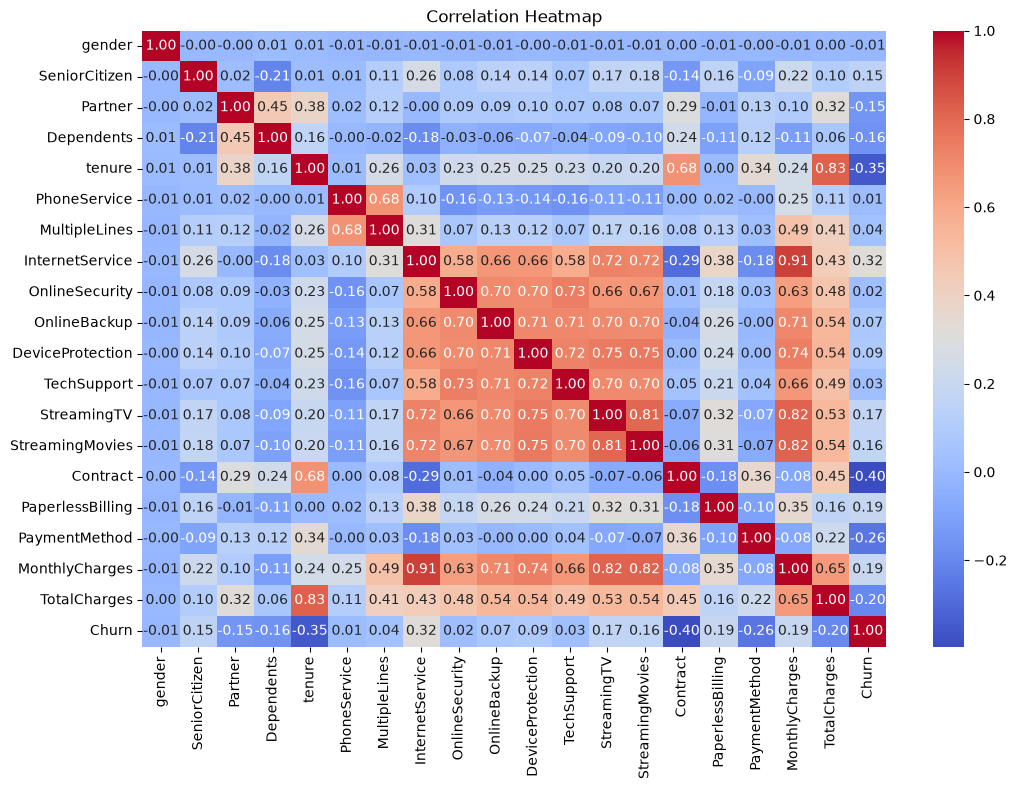

In [407]:
# Visualize the correlation between numerical features using a heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

#### Final Insights from the Data

In [408]:
# Display the correlation of all numerical features with the target variable (Churn)
corr = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

print(corr)

Churn               1.000000
InternetService     0.316967
MonthlyCharges      0.194008
PaperlessBilling    0.190518
StreamingTV         0.165909
StreamingMovies     0.164072
SeniorCitizen       0.151270
DeviceProtection    0.085297
OnlineBackup        0.074780
MultipleLines       0.037266
TechSupport         0.027219
OnlineSecurity      0.023460
PhoneService        0.011072
gender             -0.008694
Partner            -0.148670
Dependents         -0.162366
TotalCharges       -0.198362
PaymentMethod      -0.261992
tenure             -0.353339
Contract           -0.395968
Name: Churn, dtype: float64


In [409]:
# Display the number of missing values in each column in descending order
df.isnull().sum().sort_values(ascending=False)

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [410]:
# save to clean data into csv file
# df.to_csv("customer_churn_cleaned.csv", index=False)

C:\Users\rehan\AppData\Local\Temp\ipykernel_2896\192416409.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No', 'Yes'])


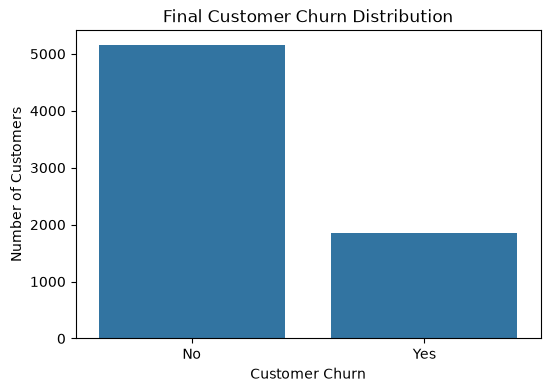

In [411]:
# Visualize the final distribution of customer churn with labeled categories
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Churn', data=df)

ax.set_xticklabels(['No', 'Yes'])

plt.title("Final Customer Churn Distribution")
plt.xlabel("Customer Churn")
plt.ylabel("Number of Customers")

plt.show()

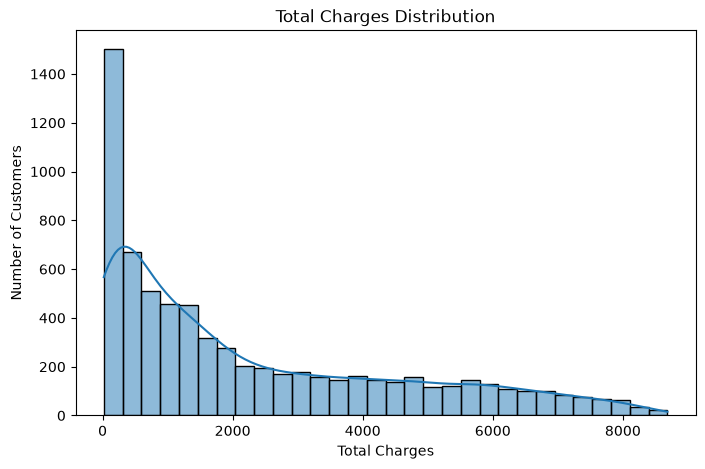

In [412]:
# Visualize the distribution of total charges using a histogram
plt.figure(figsize=(8,5))

sns.histplot(df['TotalCharges'], bins=30, kde=True)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

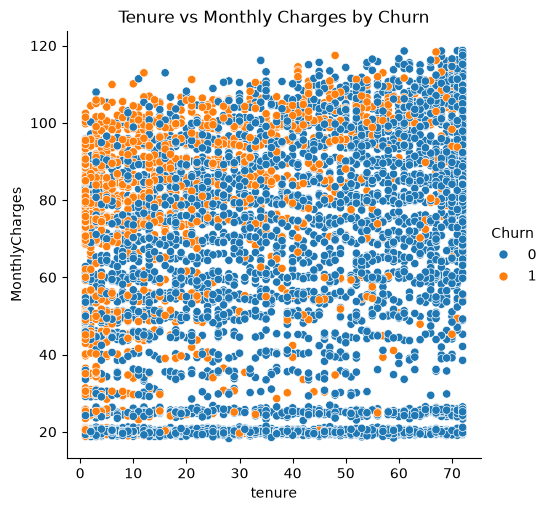

In [413]:
# Visualize the relationship between tenure and monthly charges based on churn categories
sns.relplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn'
)

plt.title("Tenure vs Monthly Charges by Churn")

plt.show()

#### sklern

In [414]:
from sklearn.model_selection import train_test_split

# Features and Target definition
x = df.drop("Churn", axis=1)
y = df["Churn"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [415]:
# Display the shape of training and testing datasets
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5608, 19)
X_test : (1402, 19)
y_train: (5608,)
y_test : (1402,)


In [416]:
# Display the training feature dataset
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
356,0,1,0,0,16,1,2,1,2,1,1,1,1,1,0,1,0,54.10,889.00
211,0,0,0,0,1,0,0,1,1,1,1,1,1,1,0,0,0,25.25,25.25
2594,0,0,1,0,65,1,2,2,1,2,2,2,2,2,2,1,2,107.65,7082.85
4641,0,0,0,0,1,0,0,1,1,1,1,1,1,1,0,0,1,24.40,24.40
2521,1,1,1,0,36,1,2,2,1,1,1,1,1,2,0,1,3,85.25,3132.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4315,0,0,0,0,1,1,1,2,1,1,1,1,2,1,0,0,0,79.55,79.55
2044,1,0,0,0,7,1,1,0,0,0,0,0,0,0,1,0,1,19.50,128.60
3873,0,0,1,1,51,0,0,1,2,1,1,2,1,1,2,0,2,34.20,1782.00
6159,0,0,0,1,2,1,1,0,0,0,0,0,0,0,1,0,2,20.50,38.25


In [417]:
# Display the training target dataset
y_train

356     0
211     0
2594    0
4641    0
2521    1
       ..
4315    1
2044    0
3873    0
6159    0
1771    1
Name: Churn, Length: 5608, dtype: int64

In [418]:
# Display the testing feature dataset
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
744,0,0,0,0,5,1,1,1,1,1,1,1,1,1,0,1,3,44.05,202.15
669,0,0,1,0,70,0,0,1,1,2,2,2,2,2,2,0,2,57.80,4039.30
5764,1,1,0,0,57,1,2,2,2,1,1,2,1,2,2,0,0,93.75,5625.55
5469,1,0,0,0,33,1,1,2,1,2,2,1,1,1,0,1,3,79.00,2576.80
2030,1,0,0,1,2,1,2,1,2,2,1,1,1,1,0,0,2,60.95,134.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,1,0,0,0,25,1,1,2,2,1,2,2,2,2,0,1,0,105.50,2686.05
5831,0,0,0,0,9,1,1,2,1,1,1,1,2,2,0,1,2,90.80,809.75
2597,1,0,1,0,71,1,2,2,2,2,2,1,2,2,1,1,0,109.60,7854.15
1343,1,0,1,1,64,1,1,1,2,1,2,1,2,2,1,1,3,73.05,4688.65


In [419]:
# Display the testing target dataset
y_test

744     0
669     0
5764    0
5469    0
2030    0
       ..
14      0
5831    1
2597    0
1343    0
3415    1
Name: Churn, Length: 1402, dtype: int64

________________________________________

#### Logistic Regression Model

In [420]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [421]:
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,0,1,1,2,1,1,1,1,0,1,0,29.85,29.85
1,1,0,0,0,34,1,1,1,2,1,2,1,1,1,1,0,1,56.95,1889.50
2,1,0,0,0,2,1,1,1,2,2,1,1,1,1,0,1,1,53.85,108.15
3,1,0,0,0,45,0,0,1,2,1,2,2,1,1,1,0,2,42.30,1840.75
4,0,0,0,0,2,1,1,2,1,1,1,1,1,1,0,1,0,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,1,2,1,2,2,2,2,1,1,1,84.80,1990.50
7039,0,0,1,1,72,1,2,2,1,2,2,1,2,2,1,1,3,103.20,7362.90
7040,0,0,1,1,11,0,0,1,2,1,1,1,1,1,0,1,0,29.60,346.45
7041,1,1,1,0,4,1,2,2,1,1,1,1,1,1,0,1,1,74.40,306.60


In [422]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7010, dtype: int64

In [423]:
#  Split the data into features (X) and target (y)
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [424]:
#  Initialize the Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)

In [425]:
#  Train the model using the training data
log_reg.fit(X_train, y_train.values.ravel())

c:\Users\rehan\OneDrive\Desktop\Data Science\boss\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [426]:
#  Predict the target values for the test data
y_pred = log_reg.predict(X_test)

In [427]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.81811697574893


In [428]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[964 117]
 [138 183]]


In [429]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88      1081
           1       0.61      0.57      0.59       321

    accuracy                           0.82      1402
   macro avg       0.74      0.73      0.74      1402
weighted avg       0.81      0.82      0.82      1402



#### Random Forest Model

In [430]:
# import libraray
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import joblib

In [431]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [432]:
base_model = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=base_model, n_features_to_select=10)
rfe.fit(X_train, y_train.values.ravel())

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",10
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,RandomForestClassifier,RandomForestC...ndom_state=42)
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_ n_features_: intThe number of selected features.,int64,np.int64(10)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,19


In [433]:
selected_features = list(X_train.columns[rfe.support_])
print("Selected Top 10 Features by RFE:", selected_features)

Selected Top 10 Features by RFE: ['gender', 'tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [434]:
X_train_rfe = X_train[selected_features]
X_test_rfe = X_test[selected_features]

In [435]:
scaler = StandardScaler()
scaler.fit(X_train_rfe)
X_train_scaled = scaler.transform(X_train_rfe)
X_test_scaled = scaler.transform(X_test_rfe)

In [436]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train.values.ravel())

In [437]:
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42
)
rf_model.fit(X_train_balanced, y_train_balanced)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [438]:
y_pred_rf = rf_model.predict(X_test_scaled)
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy Score: 0.7639087018544936
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.77      0.83      1081
           1       0.49      0.76      0.59       321

    accuracy                           0.76      1402
   macro avg       0.70      0.76      0.71      1402
weighted avg       0.82      0.76      0.78      1402



In [ ]:
# joblib.dump(rf_model, 'customer_churn_rf_model.pkl')

['customer_churn_rf_model.pkl']

In [ ]:
# joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [441]:
df[['gender', 'tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges','Churn']].to_csv("Final_data.csv",index=False)